In [1]:
"""
PHASE 1: Dimensionality Reduction and Feature Selection
Target: Extract the most impactful features for the Early Warning System
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [2]:
# Update these with your actual file paths
RTF1_FILE = 'data/PHL-PSA-FLEMMS-2024-V1-PUF/FLEMMS PUF 2024 Volume1 - RTF1.CSV'  # Household
RTF2_FILE = 'data/PHL-PSA-FLEMMS-2024-V1-PUF/FLEMMS PUF 2024 Volume1 - RTF2.CSV'  # Literacy (Target)
RTF3_FILE = 'data/PHL-PSA-FLEMMS-2024-V2-PUF/FLEMMS PUF 2024 Volume2 - RTF3.CSV'  # ICT/Digital
MEMBER_FILE = 'data/PHL-PSA-FLEMMS-2024-V1-PUF/FLEMMS PUF 2024 Volume1 - MEMBER.CSV' # Demographics

def load_and_merge_flemms():
    print("Loading datasets...")
    df_member = pd.read_csv(MEMBER_FILE)
    df_rtf1 = pd.read_csv(RTF1_FILE)
    df_rtf2 = pd.read_csv(RTF2_FILE)
    df_rtf3 = pd.read_csv(RTF3_FILE)
    
    print("Cleaning duplicate geographic columns before merging...")
    # These are the columns the PSA repeats in every file. 
    # We will keep them ONLY in df_member to prevent the MergeError.
    overlap_cols = ['REG', 'PRV', 'MUN', 'BGY', 'URBANITY', 'REG2']
    
    def remove_overlaps(df, merge_keys):
        # Drop the repeating columns if they exist in this specific dataframe
        cols_to_drop = [c for c in overlap_cols if c in df.columns and c not in merge_keys]
        return df.drop(columns=cols_to_drop)

    # Clean RTF1 (Merges on HHID only)
    df_rtf1 = remove_overlaps(df_rtf1, merge_keys=['HHID'])
    
    # Clean RTF2 (Rename LNO_F2 first, then drop overlaps)
    if 'LNO_F2' in df_rtf2.columns: 
        df_rtf2 = df_rtf2.rename(columns={'LNO_F2': 'LNO'})
    df_rtf2 = remove_overlaps(df_rtf2, merge_keys=['HHID', 'LNO'])
    
    # Clean RTF3 (Rename LNO_F3 first, then drop overlaps)
    if 'LNO_F3' in df_rtf3.columns: 
        df_rtf3 = df_rtf3.rename(columns={'LNO_F3': 'LNO'})
    df_rtf3 = remove_overlaps(df_rtf3, merge_keys=['HHID', 'LNO'])

    print("Merging datasets...")
    # Now the merges will execute perfectly without suffix collisions
    df_merged = df_member.merge(df_rtf1, on='HHID', how='left')
    df_merged = df_merged.merge(df_rtf2, on=['HHID', 'LNO'], how='left')
    df_merged = df_merged.merge(df_rtf3, on=['HHID', 'LNO'], how='left')
    
    # Filter for the 10-64 age Universe
    if 'AGE' in df_merged.columns:
        df_merged = df_merged[(df_merged['AGE'] >= 10) & (df_merged['AGE'] <= 64)]
    elif 'age' in df_merged.columns:
        df_merged = df_merged[(df_merged['age'] >= 10) & (df_merged['age'] <= 64)]
        
    print(f"Final merged shape (Ages 10-64): {df_merged.shape}")
    
    return df_merged

df = load_and_merge_flemms()

Loading datasets...
Cleaning duplicate geographic columns before merging...
Merging datasets...
Final merged shape (Ages 10-64): (496770, 196)


In [3]:
import gc

def preprocess_for_pca_memory_safe(data, target_col='FLITERATE'):
    print("Starting preprocessing...")
    
    # 1. Broaden the identifier drop list to ensure no geographic IDs explode the memory
    # Broaden the drop list to include ALL target leakage, weights, PSUs, and duplicates
    identifiers = [
        'HHID', 'LNO', 'REG', 'PRV', 'MUN', 'BGY', 'URBANITY', 'REG2', 
        'RESP_RFACT_F2', 'MEM_RFACT', 'PSU', 'PSU_MEM', 'PSU_F1', 'PSU_F2', 'PSU_F3', 'RESULT_CODE_F2', 'RESULT_CODE_F3', # Survey Metadata
        'AGE_F2', 'AGE_F3', 'AGE_rtf2', 'AGE_rtf3', 'SEX_F2', 'SEX_F3', # Duplicates from merges
        'FLLEVEL', 'FLLEVEL_0', 'COMPUTE', 'WRITING', 'READING', 'NUMERACY', 'BASIC_LIT', 'BLITERATE' # Target Leakage
    ]
    drop_cols = [c for c in identifiers + [target_col] if c in data.columns]
    
    features = data.drop(columns=drop_cols)
    print(f"Shape after dropping IDs: {features.shape}")
    
    # 2. Identify column types
    categorical_cols = features.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric_cols = features.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
    
    # 3. RAM Protection: Drop hidden high-cardinality columns
    safe_categorical_cols = []
    for col in categorical_cols:
        unique_count = features[col].nunique()
        if unique_count > 50: # Cap at 50 unique values per column
            print(f"  -> Dropping '{col}' to save RAM ({unique_count} unique values is too high for PCA)")
            features = features.drop(columns=[col])
        else:
            safe_categorical_cols.append(col)
            
    categorical_cols = safe_categorical_cols

    # 4. Impute Missing Data
    print("Imputing missing values...")
    num_imputer = SimpleImputer(strategy='median')
    if numeric_cols:
        features[numeric_cols] = num_imputer.fit_transform(features[numeric_cols])
    
    cat_imputer = SimpleImputer(strategy='constant', fill_value='Not_Applicable')
    if categorical_cols:
        features[categorical_cols] = cat_imputer.fit_transform(features[categorical_cols])
    
    # 5. Memory-Efficient One-Hot Encoding
    print("Encoding categorical variables (Memory-Safe Mode)...")
    # dtype=np.uint8 forces pandas to use 1 byte per cell instead of 8 bytes
    features_encoded = pd.get_dummies(features, columns=categorical_cols, drop_first=True, dtype=np.uint8)
    
    # FREE UP RAM: Delete the unencoded dataframe and force garbage collection
    del features 
    gc.collect() 
    
    feature_names = features_encoded.columns
    print(f"Encoded shape: {features_encoded.shape}")
    
    # 6. Scaling
    print("Scaling features...")
    scaler = StandardScaler()
    # StandardScaler converts to float64, so we cast to float32 to save 50% RAM
    X_scaled = scaler.fit_transform(features_encoded).astype(np.float32)
    
    # FREE UP RAM again
    del features_encoded
    gc.collect()
    
    print(f"Preprocessing complete. Total features for PCA: {len(feature_names)}")
    return X_scaled, feature_names

# Run the memory-safe version
X_scaled, feature_names = preprocess_for_pca_memory_safe(df, target_col='FLITERATE')

Starting preprocessing...
Shape after dropping IDs: (496770, 171)
  -> Dropping 'HGC_GRADE' to save RAM (595 unique values is too high for PCA)
  -> Dropping 'HGC_GRADE_F2' to save RAM (595 unique values is too high for PCA)
  -> Dropping 'TVOCCOURSE' to save RAM (448 unique values is too high for PCA)
  -> Dropping 'HGC_GRADE_F3' to save RAM (595 unique values is too high for PCA)
Imputing missing values...
Encoding categorical variables (Memory-Safe Mode)...
Encoded shape: (496770, 656)
Scaling features...
Preprocessing complete. Total features for PCA: 656


Fitting PCA...
Components needed to explain 95.0% of variance: 451


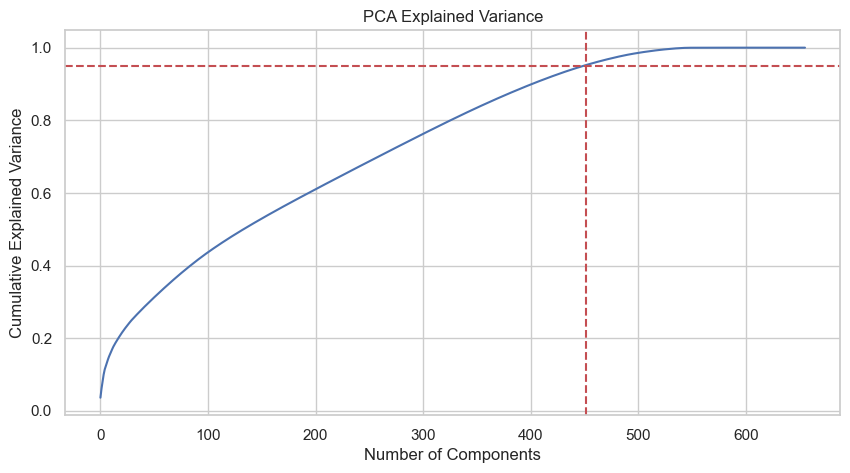

In [4]:
def run_pca(X, variance_threshold=0.95):
    print("Fitting PCA...")
    # Fit initial PCA to determine components
    pca_full = PCA()
    pca_full.fit(X)
    
    # Calculate cumulative variance
    cumsum = np.cumsum(pca_full.explained_variance_ratio_)
    n_components = np.argmax(cumsum >= variance_threshold) + 1
    
    print(f"Components needed to explain {variance_threshold*100}% of variance: {n_components}")
    
    # Refit with optimal components
    pca_final = PCA(n_components=n_components)
    X_pca = pca_final.fit_transform(X)
    
    # Plot the variance explained
    plt.figure(figsize=(10, 5))
    plt.plot(cumsum)
    plt.axvline(x=n_components, color='r', linestyle='--')
    plt.axhline(y=variance_threshold, color='r', linestyle='--')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA Explained Variance')
    plt.show()
    
    return pca_final, X_pca

pca_model, X_pca = run_pca(X_scaled)

In [5]:
def extract_top_features(pca, feature_names, top_n_components=10, features_per_comp=5):
    selected_features = set()
    
    # Get the absolute loadings
    loadings = np.abs(pca.components_)
    
    print(f"--- Top Features from Principal Components ---")
    for i in range(min(top_n_components, len(pca.components_))):
        # Sort features by loading magnitude for this component
        top_indices = np.argsort(loadings[i])[::-1][:features_per_comp]
        top_features_comp = [feature_names[idx] for idx in top_indices]
        
        print(f"PC{i+1} Dominant Features: {top_features_comp}")
        selected_features.update(top_features_comp)
    
    final_feature_list = list(selected_features)
    print(f"\nPhase 1 Complete! Extracted {len(final_feature_list)} unique high-impact features.")
    
    return final_feature_list

# Get the final list of features
phase_1_features = extract_top_features(pca_model, feature_names)

# Save the list to use in Phase 2 Notebook
pd.Series(phase_1_features).to_csv('phase1_selected_features.csv', index=False, header=['Feature_Name'])
print("Saved selected features to 'phase1_selected_features.csv'")

--- Top Features from Principal Components ---
PC1 Dominant Features: ['INTERNET_1', 'DSKILL_COM1_1', 'INTERNET_2', 'DSKILL_INFO1_1', 'DSKILL_INFO2_1']
PC2 Dominant Features: ['DSKILL_CONT5_2', 'DSKILL_CONT3_2', 'DSKILL_CONT1_2', 'DSKILL_CONT2_2', 'DSKILL_PROB3_2']
PC3 Dominant Features: ['ATTEND_SCHOOL_1', 'AGE', 'PATHWAY_COLLEGE_2', 'FATHER', 'PATHWAY_OTHERS_2']
PC4 Dominant Features: ['MM_GSERV_0', 'MM_REPORTS_0', 'MM_MEETINGS_0', 'MM_ECOMMERCE_0', 'MM_CONTENT_0']
PC5 Dominant Features: ['DIFF_COMMUNICATING_1', 'DIFF_SELFCARE_1', 'OF_PRESENT_2', 'DIFF_REMEMBERING_1', 'OF']
PC6 Dominant Features: ['TVOCAT_1', 'TVOCGRAD_1', 'TVOCCERT_3', 'TVOCBENE_11', 'TVOCBENE_ 1']
PC7 Dominant Features: ['MM_MAGAZINE_2', 'MM_POSTERS_2', 'MM_PNPAPER_2', 'MM_MEETINGS_2', 'MM_OLNPAPER_2']
PC8 Dominant Features: ['PATHWAY_OTHERS_2', 'PATHWAY_STUDYABROAD_2', 'WORK_2', 'PATHWAY_WORKABROAD_2', 'ATTEND_GRADE_LEVEL_1']
PC9 Dominant Features: ['TVOCAT_1', 'WORK_2', 'SPORTS_1', 'TVOCGRAD_1', 'TVOCCERT_3']
PC1

In [6]:
"""
PHASE 2: The Early Warning System (EWS) Predictive Model
Target: Train an XGBoost model using the 44 PCA-selected features to predict Functional Literacy
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
import gc
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# --- 1. SET FILE PATHS ---
RTF1_FILE = 'data/PHL-PSA-FLEMMS-2024-V1-PUF/FLEMMS PUF 2024 Volume1 - RTF1.CSV'  
RTF2_FILE = 'data/PHL-PSA-FLEMMS-2024-V1-PUF/FLEMMS PUF 2024 Volume1 - RTF2.CSV'  
RTF3_FILE = 'data/PHL-PSA-FLEMMS-2024-V2-PUF/FLEMMS PUF 2024 Volume2 - RTF3.CSV'  
MEMBER_FILE = 'data/PHL-PSA-FLEMMS-2024-V1-PUF/FLEMMS PUF 2024 Volume1 - MEMBER.CSV' 
PHASE1_FEATURES_FILE = 'phase1_selected_features.csv'

# --- 2. LOAD AND MERGE RAW DATA ---
print("Loading raw datasets...")
df_member = pd.read_csv(MEMBER_FILE)
df_rtf1 = pd.read_csv(RTF1_FILE)
df_rtf2 = pd.read_csv(RTF2_FILE)
df_rtf3 = pd.read_csv(RTF3_FILE)

print("Cleaning overlaps and merging...")
overlap_cols = ['REG', 'PRV', 'MUN', 'BGY', 'URBANITY', 'REG2']

def remove_overlaps(df, merge_keys):
    cols_to_drop = [c for c in overlap_cols if c in df.columns and c not in merge_keys]
    return df.drop(columns=cols_to_drop)

df_rtf1 = remove_overlaps(df_rtf1, merge_keys=['HHID'])

if 'LNO_F2' in df_rtf2.columns: df_rtf2 = df_rtf2.rename(columns={'LNO_F2': 'LNO'})
df_rtf2 = remove_overlaps(df_rtf2, merge_keys=['HHID', 'LNO'])

if 'LNO_F3' in df_rtf3.columns: df_rtf3 = df_rtf3.rename(columns={'LNO_F3': 'LNO'})
df_rtf3 = remove_overlaps(df_rtf3, merge_keys=['HHID', 'LNO'])

df_merged = df_member.merge(df_rtf1, on='HHID', how='left')
df_merged = df_merged.merge(df_rtf2, on=['HHID', 'LNO'], how='left')
df_merged = df_merged.merge(df_rtf3, on=['HHID', 'LNO'], how='left')

# Universe filter: 10-64 years old
age_col = 'AGE' if 'AGE' in df_merged.columns else 'age'
df_merged = df_merged[(df_merged[age_col] >= 10) & (df_merged[age_col] <= 64)]

print(f"Merged Data Shape: {df_merged.shape}")

# --- 3. PREPARE THE 44 PCA FEATURES ---
print("Encoding features to match Phase 1...")
# Load the golden features list
selected_features = pd.read_csv(PHASE1_FEATURES_FILE)['Feature_Name'].tolist()

# Identify the columns needed from raw data (we need to encode them again)
# We drop all metadata except the exact things we need for modeling
metadata_cols = ['HHID', 'LNO', 'PRV', 'MUN', 'RESP_RFACT_F2', 'FLITERATE']
raw_features = df_merged.drop(columns=[c for c in metadata_cols if c in df_merged.columns], errors='ignore')

# Identify categorical columns to encode
cat_cols = raw_features.select_dtypes(include=['object', 'category']).columns.tolist()

# Fill Missing Data
raw_features[cat_cols] = raw_features[cat_cols].fillna('Not_Applicable')

# One Hot Encode
encoded_features = pd.get_dummies(raw_features, columns=cat_cols, drop_first=True, dtype=np.uint8)

# Filter down to ONLY the 44 columns Phase 1 selected
# Handle slight naming variations safely
available_features = [f for f in selected_features if f in encoded_features.columns]
X = encoded_features[available_features]

# --- Prepare Target and Weights ---
print("Cleaning target variable...")

# Force convert to numeric. 'coerce' turns spaces, letters, or blanks into true NaNs
df_merged['FLITERATE'] = pd.to_numeric(df_merged['FLITERATE'], errors='coerce')

# NOW we can safely drop individuals who have missing FLITERATE scores
valid_indices = df_merged['FLITERATE'].notna()

X = X[valid_indices]
y = df_merged.loc[valid_indices, 'FLITERATE'].astype(int)
weights = df_merged.loc[valid_indices, 'RESP_RFACT_F2'].fillna(1.0) # Fallback to 1 if weight is missing

# Adjust Target format if PSA uses 1=Literate, 2=Illiterate (Make it 0=Literate, 1=Illiterate)
if y.max() == 2:
    y = (y == 2).astype(int)
    print("Adjusted target: 0 = Literate, 1 = Illiterate")

# --- 4. TRAIN THE XGBOOST MODEL ---
print("Splitting data into Training/Testing (80/20)...")
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.20, random_state=42, stratify=y
)

print(f"Training XGBoost on {len(X_train)} samples using Survey Weights...")
# Scale_pos_weight balances the fact that most people are literate
illiterate_count = np.sum(y_train == 1)
literate_count = np.sum(y_train == 0)
scale_weight = literate_count / illiterate_count if illiterate_count > 0 else 1

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_weight, 
    random_state=42,
    eval_metric='auc'
)

# Fit model
model.fit(X_train, y_train, sample_weight=w_train)

import shap
import itertools

# --- 5. EVALUATE AND EXPORT TO CSV ---
print("\n--- MODEL PERFORMANCE ---")
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# 1. Export Basic Feature Importance
print("Exporting Basic Feature Importance...")
imp_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
imp_df.to_csv('xgboost_basic_importance.csv', index=False)

# 2. Export SHAP Directional Impacts
print("Calculating SHAP Directional Impacts...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap_impact = np.abs(shap_values).mean(axis=0)
correlation_direction = np.nan_to_num([np.corrcoef(X_test.iloc[:, i], shap_values[:, i])[0, 1] for i in range(X_test.shape[1])])

shap_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Average_Impact_Magnitude': shap_impact,
    'Effect_Direction': correlation_direction
}).sort_values(by='Average_Impact_Magnitude', ascending=False)

def interpret_effect(row):
    if row['Effect_Direction'] > 0: return "Increases Risk"
    elif row['Effect_Direction'] < 0: return "Decreases Risk"
    else: return "Neutral"

shap_df['Policy_Interpretation'] = shap_df.apply(interpret_effect, axis=1)
shap_df.to_csv('xgboost_shap_ale_impact.csv', index=False)

# 3. Export SHAP Feature Interactions (The Compounding Risks)
print("Calculating SHAP Feature Interactions (Optimized for speed)...")

# THE FIX: Take a random, representative sample of 2,000 rows
# This gives the same statistical insights but takes 1 minute instead of 3 hours
sample_size = min(2000, len(X_test))
X_test_sampled = X_test.sample(n=sample_size, random_state=42)

# Calculate the exact interaction matrix ONLY on the sample
interaction_values = explainer.shap_interaction_values(X_test_sampled)

# Average the interaction magnitudes across the sample
mean_interactions = np.abs(interaction_values).mean(axis=0)

# Unpack the 2D matrix into a clean, readable list of Feature Pairs
interaction_list = []
features = X_test_sampled.columns
for i in range(len(features)):
    for j in range(i + 1, len(features)):  # Start at i+1 to avoid self-interactions
        interaction_list.append({
            'Feature_A': features[i],
            'Feature_B': features[j],
            'Interaction_Strength': mean_interactions[i, j]
        })

interaction_pairs_df = pd.DataFrame(interaction_list).sort_values(by='Interaction_Strength', ascending=False)

# Save the top 30 strongest interacting pairs
interaction_pairs_df.head(30).to_csv('xgboost_shap_interactions.csv', index=False)
print("✅ Saved 'xgboost_shap_interactions.csv'")
print("\nPhase 2 Complete! Check your folder for the exported CSV files.")

Loading raw datasets...
Cleaning overlaps and merging...
Merged Data Shape: (496770, 196)
Encoding features to match Phase 1...
Cleaning target variable...
Adjusted target: 0 = Literate, 1 = Illiterate
Splitting data into Training/Testing (80/20)...
Training XGBoost on 374914 samples using Survey Weights...

--- MODEL PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.79      0.70      0.74     65074
           1       0.46      0.59      0.52     28655

    accuracy                           0.66     93729
   macro avg       0.63      0.64      0.63     93729
weighted avg       0.69      0.66      0.67     93729

Exporting Basic Feature Importance...
Calculating SHAP Directional Impacts...
Calculating SHAP Feature Interactions (Optimized for speed)...
✅ Saved 'xgboost_shap_interactions.csv'

Phase 2 Complete! Check your folder for the exported CSV files.
